# **Interpretabilidad con LIME**

En esta sección se aplica LIME (*Local Interpretable Model-agnostic Explanations*) con el fin de interpretar localmente las predicciones del modelo de clasificación construido con scikit-learn.

Siguiendo la guía del proyecto, se seleccionarán una o dos instancias clasificadas erróneamente para analizar cuáles variables influyeron más en la predicción realizada por el modelo.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from lime.lime_tabular import LimeTabularExplainer

In [3]:
DATA_PATH = Path(r"C:\Users\Daniel Rangel\Documents\MachineLearning\Data\accepted_2007_to_2018Q4.csv.gz")

df = pd.read_csv(DATA_PATH, low_memory=False)
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

num_vars = [
    "loan_amnt",
    "int_rate",
    "fico_range_high",
    "annual_inc",
    "dti",
    "revol_util",
    "open_acc",
    "total_acc"
]

cat_vars = [
    "emp_length",
    "purpose",
    "home_ownership",
    "addr_state"
]

selected_vars = num_vars + cat_vars

df_model = df[selected_vars + ["default"]].copy()

X = df_model[selected_vars]
y = df_model["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_vars),
        ("cat", categorical_transformer, cat_vars)
    ]
)

best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        max_depth=15,
        n_estimators=10
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [5]:
errors_df = X_test.copy()
errors_df["y_true"] = y_test.values
errors_df["y_pred"] = y_pred
errors_df["y_proba_1"] = y_proba

false_negatives = errors_df[(errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0)]

print("Número de falsos negativos:", false_negatives.shape[0])
false_negatives.head()

Número de falsos negativos: 53712


,loan_amnt,int_rate,fico_range_high,annual_inc,dti,revol_util,open_acc,total_acc,emp_length,purpose,home_ownership,addr_state,y_true,y_pred,y_proba_1
1023051,10000.0,6.97,714.0,55000.0,18.28,76.2,8.0,23.0,10+ years,credit_card,MORTGAGE,NY,1,0,0.053073
329340,9175.0,15.61,674.0,50000.0,8.59,53.0,11.0,33.0,5 years,debt_consolidation,MORTGAGE,NY,1,0,0.181765
267583,21375.0,15.61,699.0,85000.0,22.43,35.8,14.0,24.0,5 years,debt_consolidation,RENT,NV,1,0,0.152464
1613386,4000.0,7.51,764.0,47000.0,15.63,4.4,18.0,30.0,7 years,debt_consolidation,RENT,NJ,1,0,0.034932
158218,11000.0,9.99,744.0,100000.0,5.03,16.9,13.0,15.0,3 years,other,RENT,NJ,1,0,0.056323


## **Preparación de LIME**

Dado que LIME trabaja en memoria local, se utilizará el modelo de scikit-learn y el conjunto de entrenamiento transformado para construir el explicador local.

El objetivo es interpretar una instancia clasificada erróneamente, identificando cuáles variables contribuyeron más a la predicción del modelo.

In [7]:
X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

print("X_train_transformed:", X_train_transformed.shape)
print("X_test_transformed:", X_test_transformed.shape)

X_train_transformed: (1808560, 90)
X_test_transformed: (452141, 90)


In [8]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print("Número de features transformadas:", len(feature_names))
feature_names[:20]

Número de features transformadas: 90


array(['num__loan_amnt', 'num__int_rate', 'num__fico_range_high',
       'num__annual_inc', 'num__dti', 'num__revol_util', 'num__open_acc',
       'num__total_acc', 'cat__emp_length_1 year',
       'cat__emp_length_10+ years', 'cat__emp_length_2 years',
       'cat__emp_length_3 years', 'cat__emp_length_4 years',
       'cat__emp_length_5 years', 'cat__emp_length_6 years',
       'cat__emp_length_7 years', 'cat__emp_length_8 years',
       'cat__emp_length_9 years', 'cat__emp_length_< 1 year',
       'cat__purpose_car'], dtype=object)

In [9]:
explainer = LimeTabularExplainer(
    training_data=X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed,
    feature_names=feature_names,
    class_names=["No Default", "Default"],
    mode="classification"
)

In [10]:
# Seleccionamos la primera instancia mal clasificada (falso negativo)
idx_instance = false_negatives.index[0]

x_instance_raw = X_test.loc[idx_instance]
x_instance_transformed = X_test_transformed[X_test.index.get_loc(idx_instance)]

print("Índice de la instancia:", idx_instance)
print("Clase real:", y_test.loc[idx_instance])
print("Clase predicha:", y_pred[X_test.index.get_loc(idx_instance)])
print("Probabilidad predicha de default:", y_proba[X_test.index.get_loc(idx_instance)])
x_instance_raw

Índice de la instancia: 1023051
Clase real: 1
Clase predicha: 0
Probabilidad predicha de default: 0.053073229501496996


loan_amnt              10000.0
int_rate                  6.97
fico_range_high          714.0
annual_inc             55000.0
dti                      18.28
revol_util                76.2
open_acc                   8.0
total_acc                 23.0
emp_length           10+ years
purpose            credit_card
home_ownership        MORTGAGE
addr_state                  NY
Name: 1023051, dtype: object

In [12]:
rf_classifier = best_model.named_steps["classifier"]

def predict_proba_transformed(x):
    return rf_classifier.predict_proba(x)

In [13]:
explanation = explainer.explain_instance(
    data_row=x_instance_transformed.toarray().ravel() if hasattr(x_instance_transformed, "toarray") else x_instance_transformed,
    predict_fn=predict_proba_transformed,
    num_features=10
)

In [14]:
explanation.as_list()

[('num__int_rate <= -0.75', -0.053969244819468146),
 ('cat__addr_state_DC <= 0.00', -0.03395334959278614),
 ('cat__addr_state_RI <= 0.00', -0.03016802899226885),
 ('cat__purpose_renewable_energy <= 0.00', 0.027209476786014562),
 ('cat__addr_state_UT <= 0.00', -0.02427692936649252),
 ('cat__addr_state_DE <= 0.00', -0.021523431183177545),
 ('cat__purpose_small_business <= 0.00', -0.017575408729062096),
 ('cat__home_ownership_OTHER <= 0.00', -0.016776883793650253),
 ('cat__addr_state_AK <= 0.00', 0.014520146096008511),
 ('cat__purpose_educational <= 0.00', 0.012315681932122343)]

## **Interpretación local con LIME**

La explicación local generada por LIME muestra cuáles variables influyeron más en la predicción realizada por el modelo para esta instancia específica, que corresponde a un **falso negativo**: un préstamo realmente en `Charged Off` (`default = 1`) pero clasificado por el modelo como `Fully Paid` (`default = 0`).

Entre los factores con mayor peso hacia la predicción de **Fully Paid**, destaca la variable `int_rate`, cuyo valor transformado aparece en un rango bajo (`num__int_rate <= -0.75`). Esto es consistente con la observación de que tasas de interés bajas suelen asociarse con menor riesgo percibido por el modelo.

También aparecen varias variables categóricas relacionadas con el estado (`addr_state`) y con el propósito del préstamo (`purpose`). En particular, la ausencia de categorías de alto riesgo como `small_business` o `renewable_energy` contribuyó a empujar la predicción hacia la clase 0.

En conjunto, la explicación sugiere que el modelo interpretó esta observación como un caso de bajo riesgo debido a señales favorables como una tasa de interés reducida y la ausencia de ciertas categorías asociadas con mayores tasas de default. Sin embargo, en la realidad se trataba de un préstamo que sí terminó en incumplimiento, lo cual evidencia una limitación del modelo para capturar todos los patrones que explican la clase positiva.

In [16]:
import matplotlib.pyplot as plt

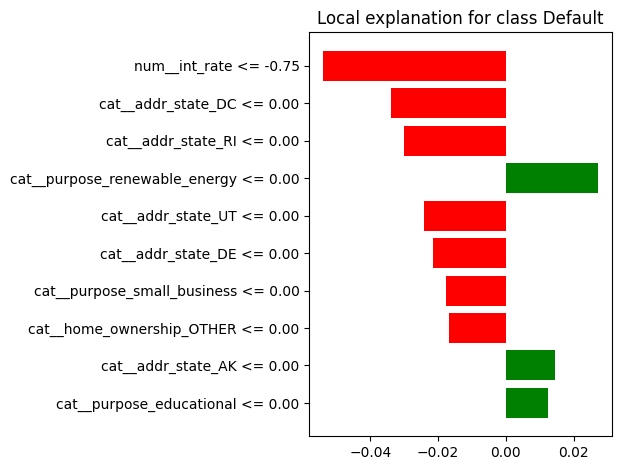

In [17]:
fig = explanation.as_pyplot_figure()
plt.tight_layout()
plt.show()

### **Visualización local de la explicación**

El gráfico local de LIME permite observar de manera visual qué variables empujaron la predicción del modelo hacia la clase **Fully Paid** y cuáles la alejaron de dicha clase.

En esta explicación, las barras verdes representan variables que aumentan la probabilidad de `Charged Off`, mientras que las barras rojas representan variables que empujan la predicción hacia la clase contraria.

Se observa que la variable con mayor influencia local es `int_rate`, cuyo valor bajo contribuyó fuertemente a que el modelo redujera la probabilidad estimada de default para esta observación. Asimismo, la ausencia de ciertas categorías asociadas con mayor riesgo, como `small_business` o `renewable_energy`.

En conjunto, la visualización confirma que el modelo basó su decisión en señales localmente coherentes con su lógica interna, aunque en este caso dichas señales no fueron suficientes para identificar correctamente el incumplimiento real de la instancia analizada.

## **Limitaciones de LIME en el contexto del proyecto**

LIME se aplicó sobre el modelo entrenado con scikit-learn, ya que esta herramienta opera en memoria local y requiere acceso directo a un modelo que pueda evaluar perturbaciones sobre instancias individuales.

En el caso de PySpark, la aplicación de LIME resulta más limitada, dado que el flujo de modelado trabaja sobre estructuras distribuidas y no está diseñado para generar explicaciones locales directamente en memoria de la misma forma que un modelo de scikit-learn.

Por esta razón, aunque LIME es útil para ilustrar la interpretabilidad local del problema, su uso es más natural y práctico sobre el modelo entrenado en scikit-learn que sobre el flujo distribuido implementado en PySpark.